# (06) fit w/ grad — (T, beta) = (10, 15.0)

project = ```iP-VAE```, host = ```mach```, device = ```cuda:2```

**Motivation**: <br>

- Q: bias and lr. should we have one number for all, or per neuron?
- A: bias should be per neuron, log_lr should be global.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## Trainer

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'grad|lin')
cfg_vae['seq_len'] = 10
cfg_vae['n_iters'] = 1

cfg_vae['init_scale'] = 1e-2
cfg_vae['track_stats'] = True

# cfg_tr['epochs'] = 1000
# cfg_vae['beta_inner'] = 1.0
cfg_tr['kl_beta'] = 15.0

cfg_tr['epochs'] = 600
cfg_tr['batch_size'] = 500

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.01, 'seq_len': 10, 'n_iters': 1, 'track_stats': True}

Trainer:
{'batch_size': 500, 'epochs': 600, 'optimizer_kws': {'weight_decay': 0.0}, 'grad_clip': 200, 'kl_beta': 15.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_vH16_t-10×1_b-1_z-[512]_<grad|lin>
b500-ep600-lr(0.002)_beta(15:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_09,15:44)

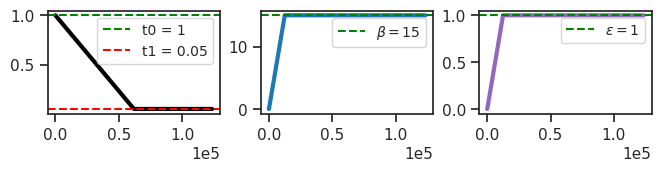

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
cm = 'bias-local_lr-global'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 600, avg loss: 261.904678: 100%|████| 600/600 [2:18:09<00:00, 13.82s/it]


epoch # 600, avg loss: 236.974520: 100%|████| 600/600 [2:26:54<00:00, 14.69s/it]


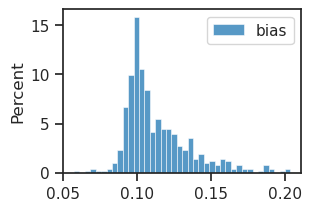

tensor([0.2127], device='cuda:2', grad_fn=<ExpBackward0>)

In [24]:
fig, ax = create_figure()

kws = dict(bins=40, stat='percent',  ax=ax)
sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', **kws)
# sns.histplot(tonp(tr.model.layer.log_lr.squeeze().exp()), label='lr', **kws)
ax.legend()
plt.show()

tr.model.layer.log_lr.exp()

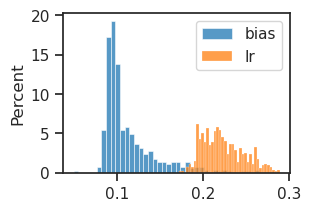

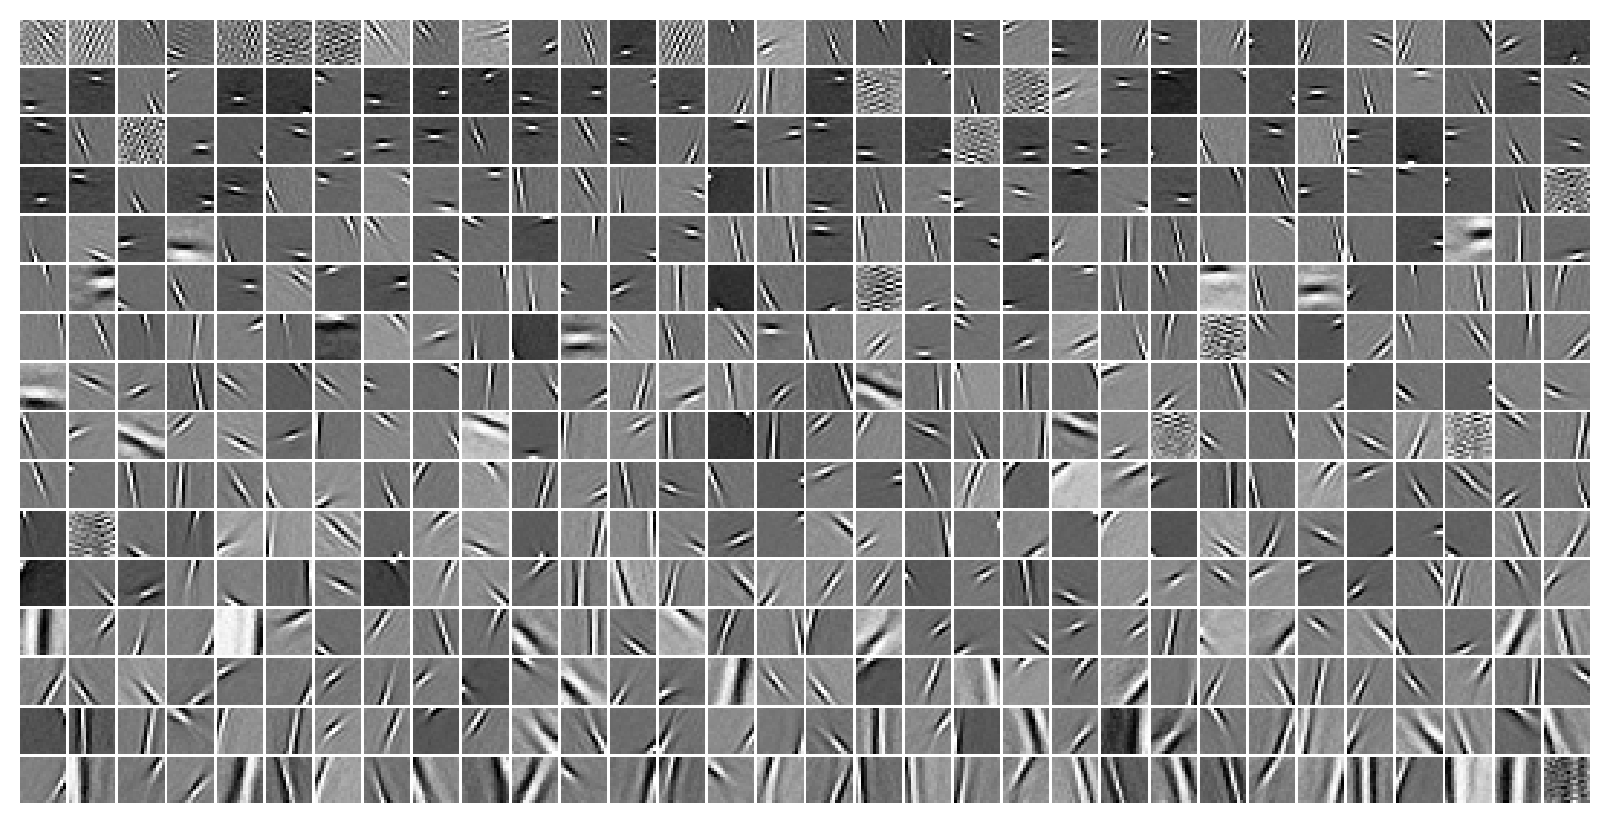

In [25]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

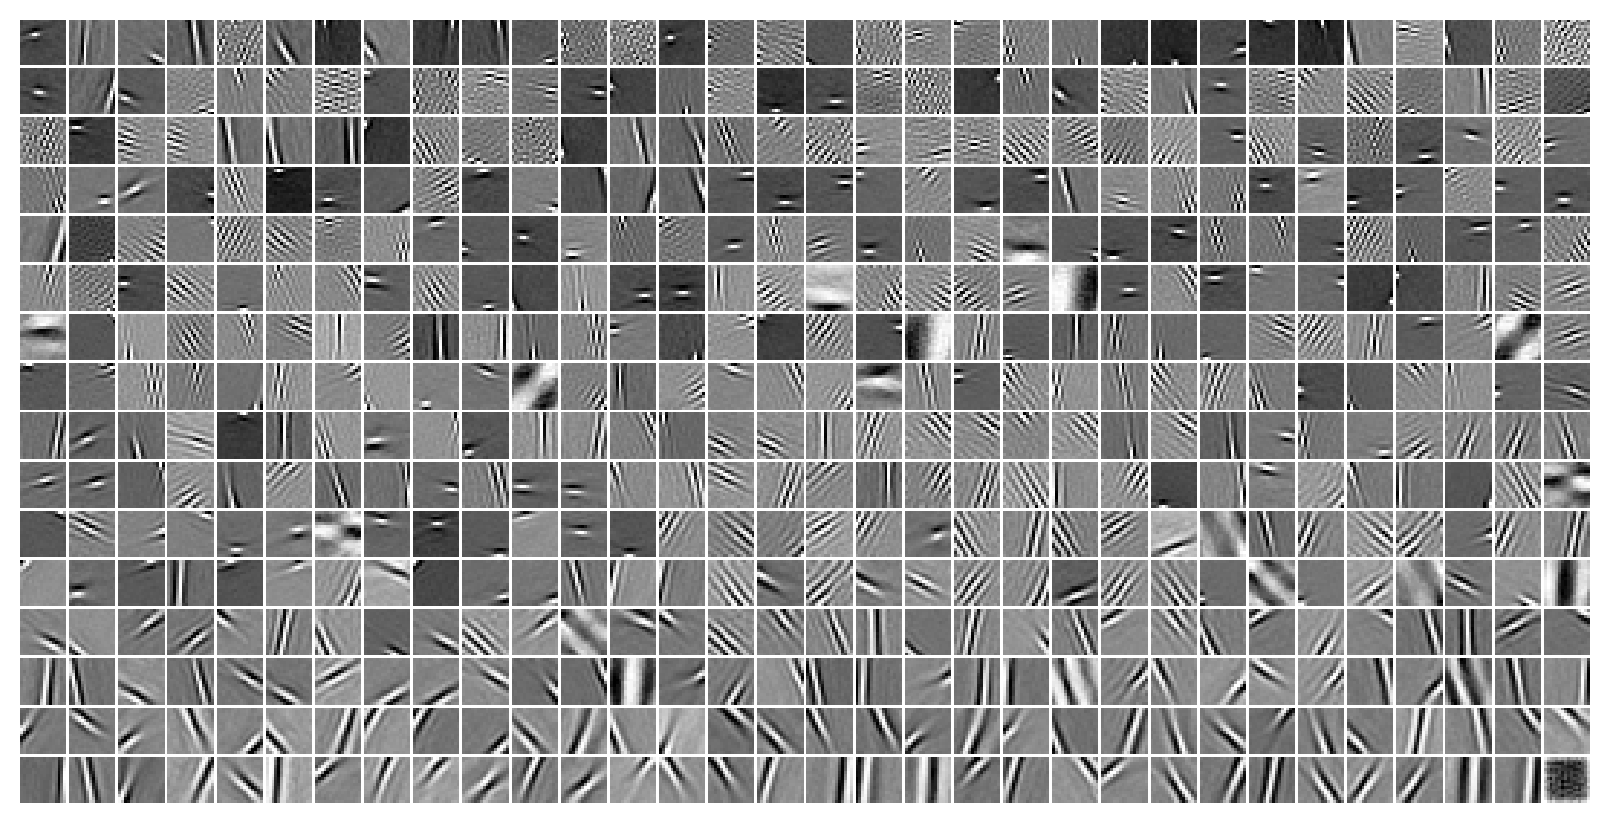

In [11]:
### Was: beta = 15.0, both local

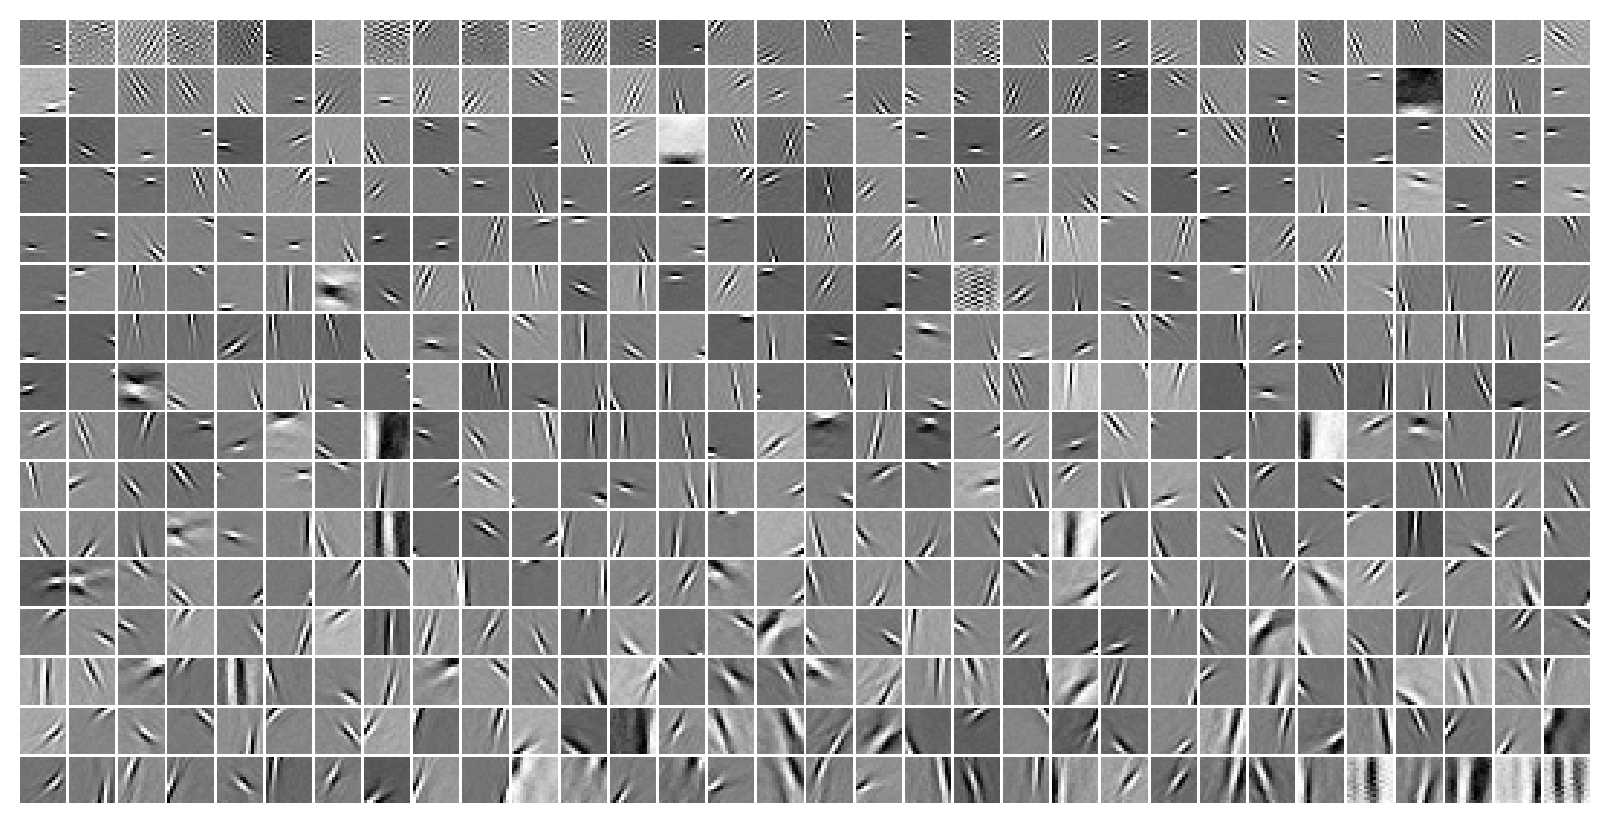

In [7]:
### Was: beta = 10.0

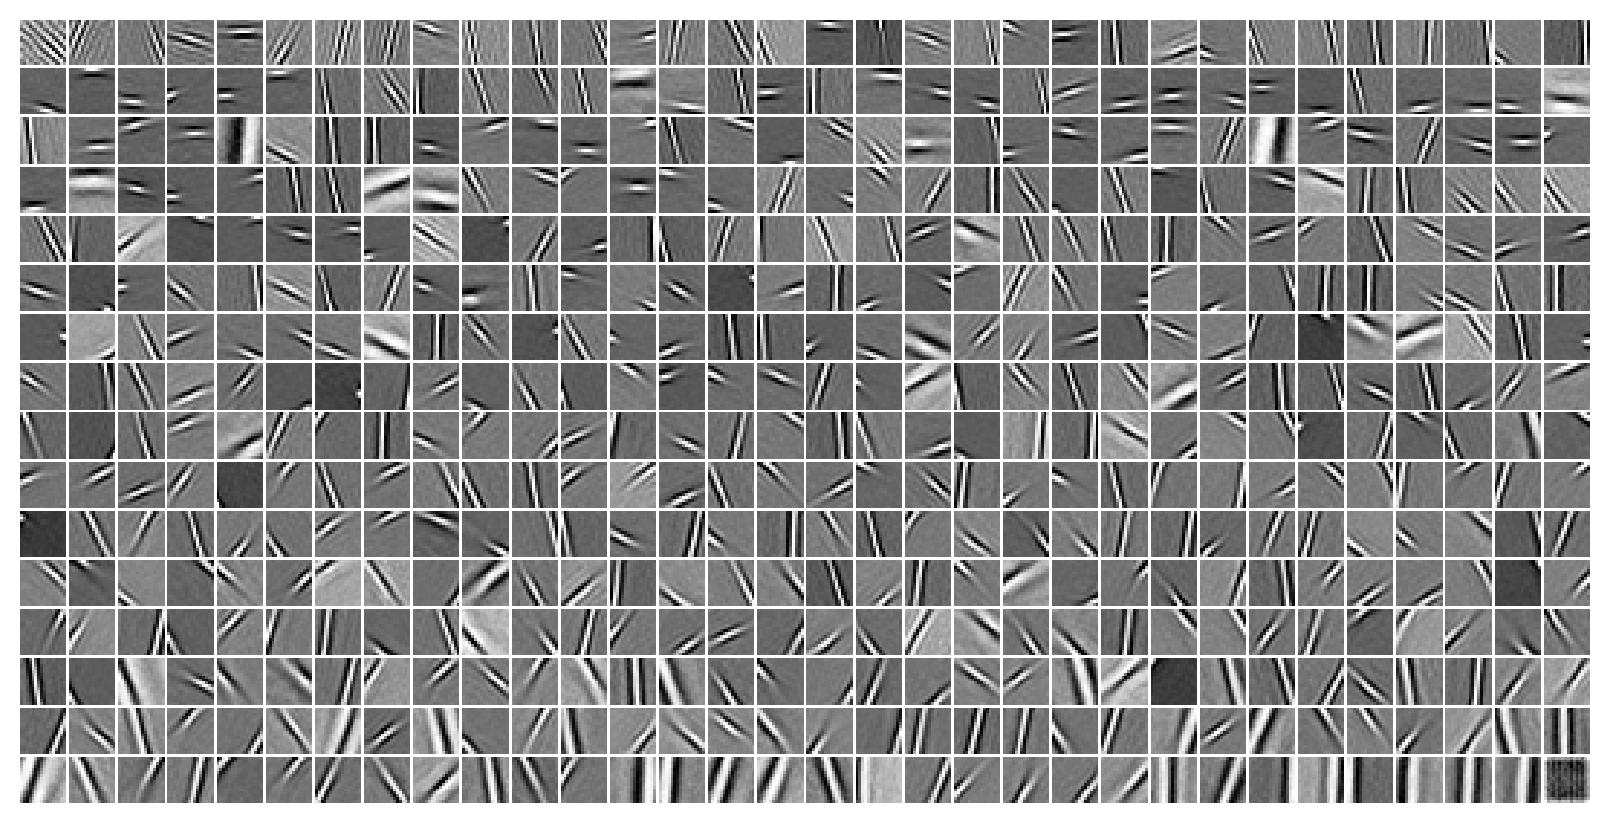

In [6]:
### grad + 8x2 + 8,8

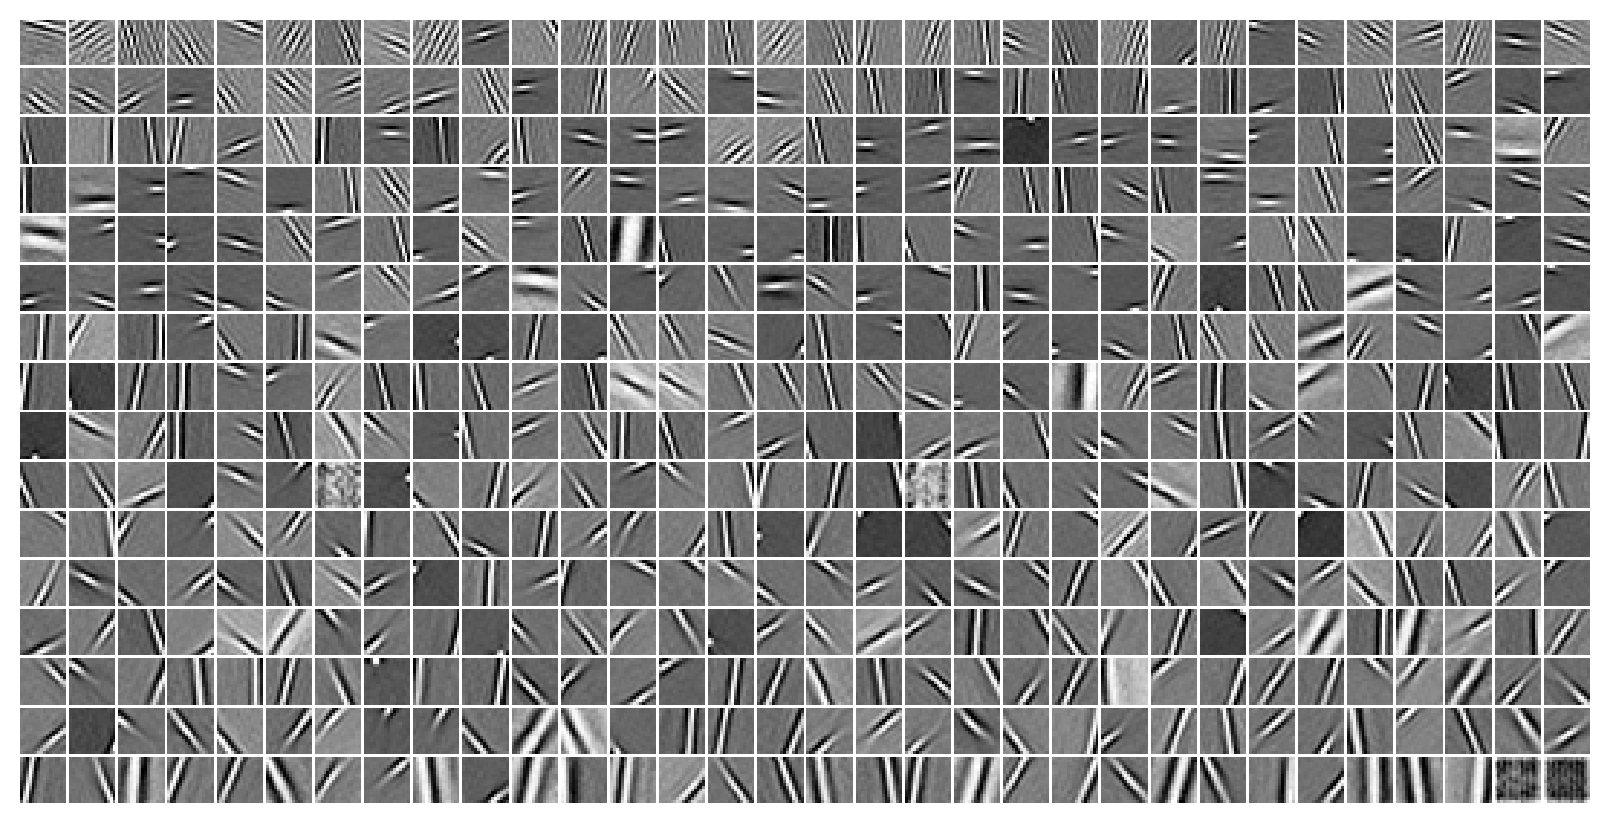

In [7]:
## Was leapfrog

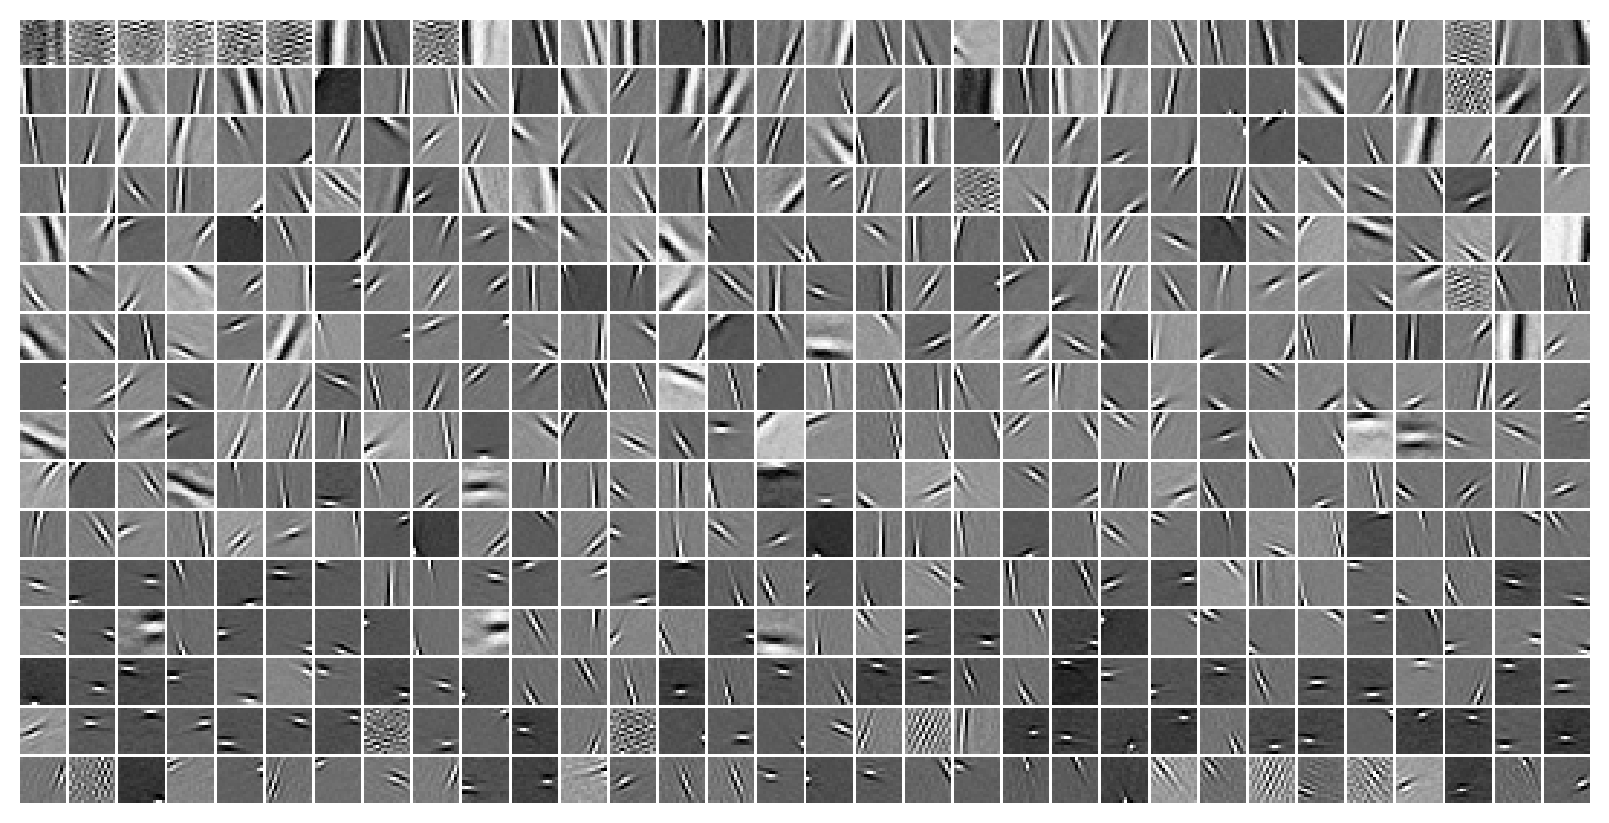

In [10]:
bias = tonp(tr.model.layer.log_bias.squeeze())
tr.model.show(order=np.argsort(bias));

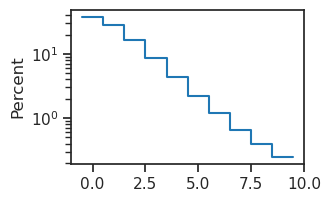

In [26]:
data, loss, etc = tr.validate()
z_last = data['z'][:, -1, :]

ax = histplot(z_last.ravel().astype(int), bins=np.linspace(0, 10, 11) - 0.5, stat='percent')
ax.set_yscale('log')

In [27]:
%%time

feeder = tr.get_feeder(next(iter(tr.dl_vld))[0])
output = tr.model.xtract_ftr(feeder, seq=range(1000), return_extras=True).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'u', 'v', 'recon', 'samples', 'conditional']

CPU times: user 2.28 s, sys: 81 ms, total: 2.36 s
Wall time: 2.35 s


[0.886345624923706,
 0.8866307735443115,
 0.8870487809181213,
 0.8867268562316895,
 0.8867517709732056]

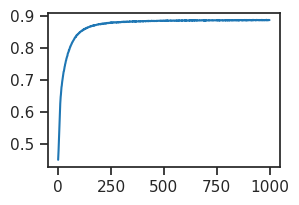

In [28]:
from analysis.sparse import sparse_score

t = 0
lifetime, population = [], []
for t in range(1000):
    life, popu, _ = sparse_score(output['samples'][:, t, :])
    lifetime.append(life.mean().item())
    population.append(popu.mean().item())


plt.plot(lifetime);
lifetime[-5:]

In [29]:
u_norm = torch.linalg.norm(output['u'], axis=-1)
v_norm = torch.linalg.norm(output['v'], axis=-1)
# a_norm = torch.linalg.norm(output['a'], axis=-1)

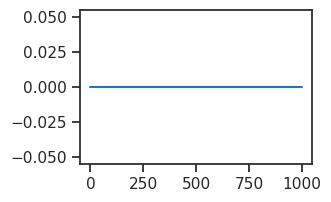

In [30]:
# plot(u_norm.mean(0), marker='o');
plot(v_norm.mean(0));

tensor([37.7039, 38.0697, 37.7636, 37.8178, 37.6593], device='cuda:2')

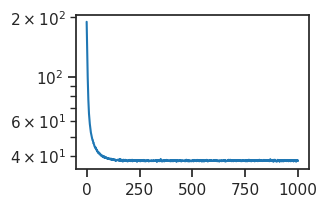

In [31]:
locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log');

mse.mean(0)[-5:]

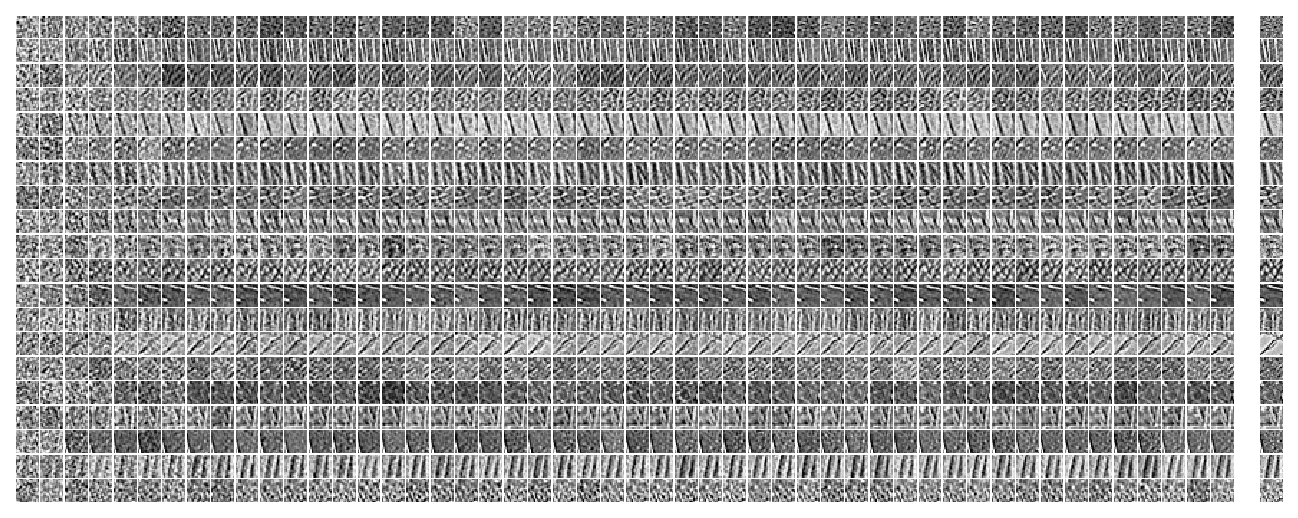

In [32]:
num = 20
n_timepoints = 50
x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

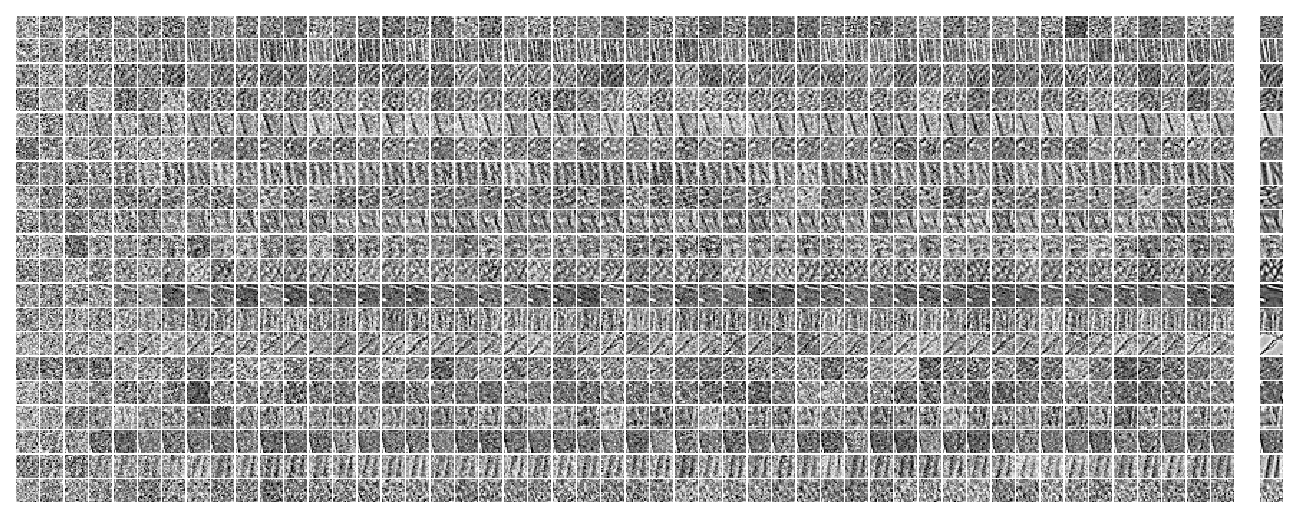

In [33]:
num = 20
n_timepoints = 50
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

tensor([0.6111, 0.6089, 0.6023, 0.6234, 0.6152], device='cuda:2')

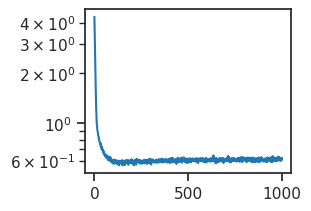

In [34]:
fig, ax = create_figure()

x2p = output['loss_kl'].sum(-1).mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([173.7737, 174.1846, 173.8356, 173.8986, 173.7207], device='cuda:2')

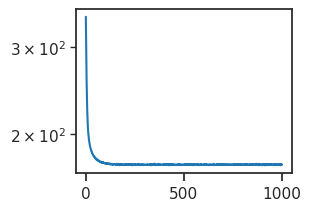

In [35]:
fig, ax = create_figure()

x2p = output['loss_recon'].mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([37.7039, 38.0697, 37.7636, 37.8178, 37.6593], device='cuda:2')

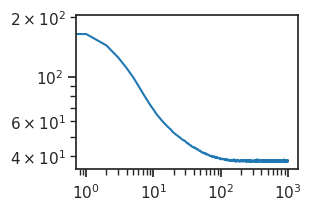

In [36]:
fig, ax = create_figure()

x2p = mse.mean(0)
plot(x2p)
ax.set(xscale='log', yscale='log');

x2p[-5:]